# Token Usage Analysis: Two-Stage Pipeline (0407)

Analyze whether Haiku (extraction) or Kimi (classification) are at risk of hitting context window or output token limits on the 9 example cases.

**Model limits:**
- Haiku 4.5: 200K context window, 64K max output tokens
- Kimi K2.5: 128K context window, 16K max output tokens

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ext = pd.read_csv('data/output/extraction_raw_results.csv')
cls = pd.read_csv('data/output/classification_raw_results.csv')

HAIKU_CONTEXT = 200_000
HAIKU_MAX_OUTPUT = 64_000
KIMI_CONTEXT = 128_000
KIMI_MAX_OUTPUT = 16_000

## Haiku Extraction — Token Usage by Opinion

In [2]:
ext['input_pct'] = ext['input_tokens'] / HAIKU_CONTEXT * 100
ext['output_pct'] = ext['output_tokens'] / HAIKU_MAX_OUTPUT * 100
ext = ext.sort_values('output_tokens')

print(ext[['citing_cluster_id', 'input_tokens', 'output_tokens', 'num_cited_cases',
           'input_pct', 'output_pct', 'stop_reason']].to_string(index=False))

 citing_cluster_id  input_tokens  output_tokens  num_cited_cases  input_pct  output_pct stop_reason
           7774813          5506            915               17     2.7530    1.429688    tool_use
            101625         11396            949               17     5.6980    1.482812    tool_use
            117849          7747           1350               24     3.8735    2.109375    tool_use
            103543          6320           1418               26     3.1600    2.215625    tool_use
            110420         11377           1644               29     5.6885    2.568750    tool_use
            110274         10190           1979               36     5.0950    3.092188    tool_use
            725046          9913           2858               54     4.9565    4.465625    tool_use
            110360         32659           3785               69    16.3295    5.914062    tool_use
            110380         38184           5295               91    19.0920    8.273438    tool_use


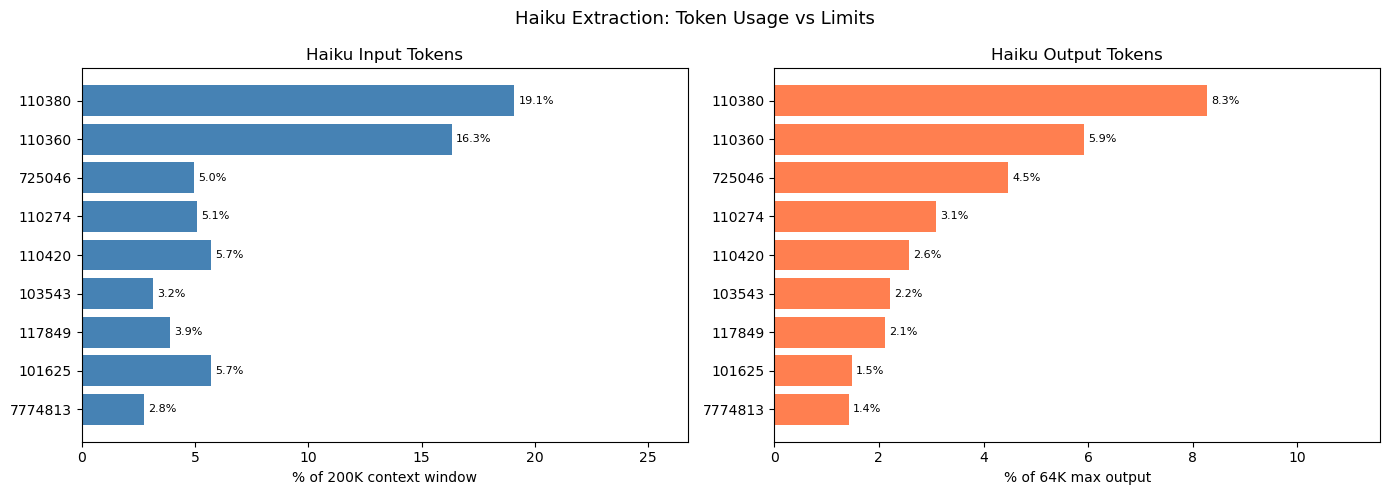

Max input usage: 19.1% of 200K — no risk
Max output usage: 8.3% of 64K — no risk


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = ext['citing_cluster_id'].astype(str)

# Input tokens
bars1 = ax1.barh(labels, ext['input_pct'], color='steelblue')
ax1.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=8)
ax1.set_xlabel('% of 200K context window')
ax1.set_title('Haiku Input Tokens')
ax1.set_xlim(0, ext['input_pct'].max() * 1.4)

# Output tokens
bars2 = ax2.barh(labels, ext['output_pct'], color='coral')
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=8)
ax2.set_xlabel('% of 64K max output')
ax2.set_title('Haiku Output Tokens')
ax2.set_xlim(0, ext['output_pct'].max() * 1.4)

plt.suptitle('Haiku Extraction: Token Usage vs Limits', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Max input usage: {ext["input_pct"].max():.1f}% of 200K — no risk')
print(f'Max output usage: {ext["output_pct"].max():.1f}% of 64K — no risk')

### Haiku: Output tokens vs number of cited cases

Output tokens scale linearly with the number of extracted citations. At what point would we hit the 64K limit?

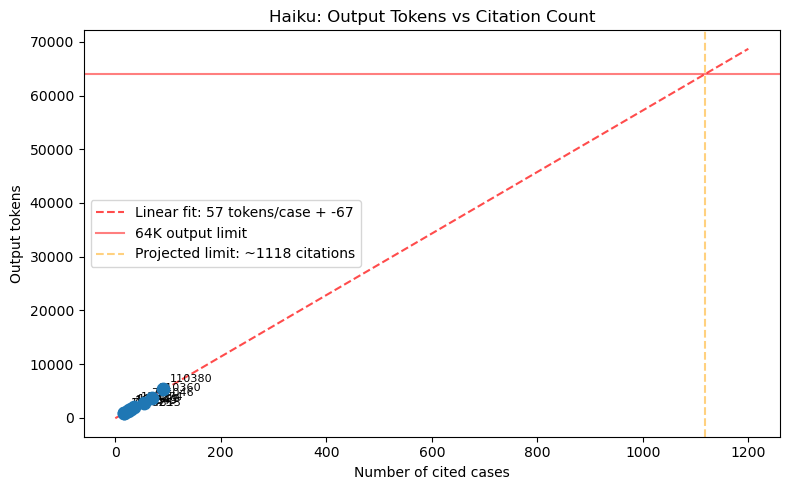

Linear model: ~57 output tokens per cited case + -67 overhead
Projected output limit at ~1118 cited cases
Current max: 91 cases (5295 tokens, 8%)


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ext['num_cited_cases'], ext['output_tokens'], s=80, zorder=5)
for _, r in ext.iterrows():
    ax.annotate(str(int(r['citing_cluster_id'])), (r['num_cited_cases'], r['output_tokens']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# Linear fit
z = np.polyfit(ext['num_cited_cases'], ext['output_tokens'], 1)
p = np.poly1d(z)
x_fit = np.linspace(0, 1200, 100)
ax.plot(x_fit, p(x_fit), 'r--', alpha=0.7, label=f'Linear fit: {z[0]:.0f} tokens/case + {z[1]:.0f}')

# Limit line
ax.axhline(y=HAIKU_MAX_OUTPUT, color='red', linestyle='-', alpha=0.5, label=f'64K output limit')

# Projected max citations before hitting limit
max_cases = (HAIKU_MAX_OUTPUT - z[1]) / z[0]
ax.axvline(x=max_cases, color='orange', linestyle='--', alpha=0.5, label=f'Projected limit: ~{max_cases:.0f} citations')

ax.set_xlabel('Number of cited cases')
ax.set_ylabel('Output tokens')
ax.set_title('Haiku: Output Tokens vs Citation Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Linear model: ~{z[0]:.0f} output tokens per cited case + {z[1]:.0f} overhead')
print(f'Projected output limit at ~{max_cases:.0f} cited cases')
print(f'Current max: {ext["num_cited_cases"].max()} cases ({ext["output_tokens"].max()} tokens, {ext["output_pct"].max():.0f}%)')

## Kimi Classification — Token Usage by Group

In [5]:
cls['input_pct'] = cls['input_tokens'] / KIMI_CONTEXT * 100
cls['output_pct'] = cls['output_tokens'] / KIMI_MAX_OUTPUT * 100

print(f'Total groups: {len(cls)}')
print(f'Groups >75% output: {(cls["output_pct"] > 75).sum()}')
print(f'Groups >75% input: {(cls["input_pct"] > 75).sum()}')
print(f'\nTop 10 by output token usage:')
print(cls.nlargest(10, 'output_tokens')[['citing_cluster_id', 'group_idx', 'num_citations',
                                          'input_tokens', 'output_tokens', 'output_pct']].to_string(index=False))

Total groups: 144
Groups >75% output: 0
Groups >75% input: 0

Top 10 by output token usage:
 citing_cluster_id  group_idx  num_citations  input_tokens  output_tokens  output_pct
           7774813          1             11          7693           6499    40.61875
            725046         10             13          6374           2406    15.03750
            110380         23             15          9983           2368    14.80000
            110274         11             15          6514           2208    13.80000
            725046         12             15          6547           2177    13.60625
            110360         22             13          6096           1793    11.20625
            110380         22              8         10112           1653    10.33125
            110380         15             11          9791           1623    10.14375
            110360         17             12          5947           1609    10.05625
            110380         21              8    

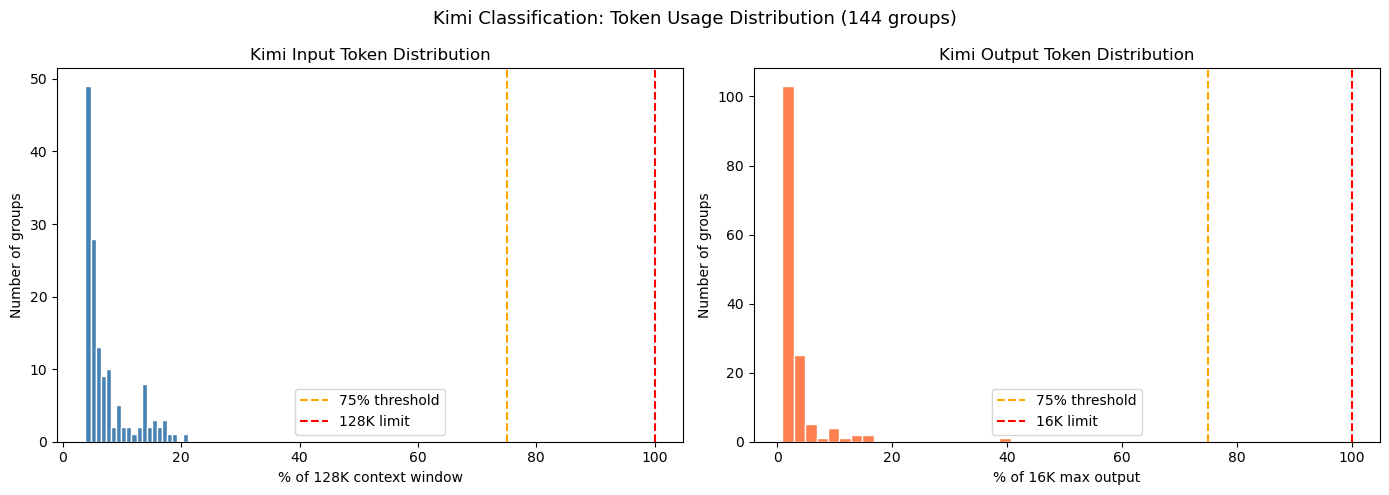

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Input distribution
ax1.hist(cls['input_pct'], bins=20, color='steelblue', edgecolor='white')
ax1.axvline(x=75, color='orange', linestyle='--', label='75% threshold')
ax1.axvline(x=100, color='red', linestyle='--', label='128K limit')
ax1.set_xlabel('% of 128K context window')
ax1.set_ylabel('Number of groups')
ax1.set_title('Kimi Input Token Distribution')
ax1.legend()

# Output distribution
ax2.hist(cls['output_pct'], bins=20, color='coral', edgecolor='white')
ax2.axvline(x=75, color='orange', linestyle='--', label='75% threshold')
ax2.axvline(x=100, color='red', linestyle='--', label='16K limit')
ax2.set_xlabel('% of 16K max output')
ax2.set_ylabel('Number of groups')
ax2.set_title('Kimi Output Token Distribution')
ax2.legend()

plt.suptitle('Kimi Classification: Token Usage Distribution (144 groups)', fontsize=13)
plt.tight_layout()
plt.show()

### Kimi: Output tokens vs number of citations per group

Groups with many citations need more output tokens. Is there a risk of truncation?

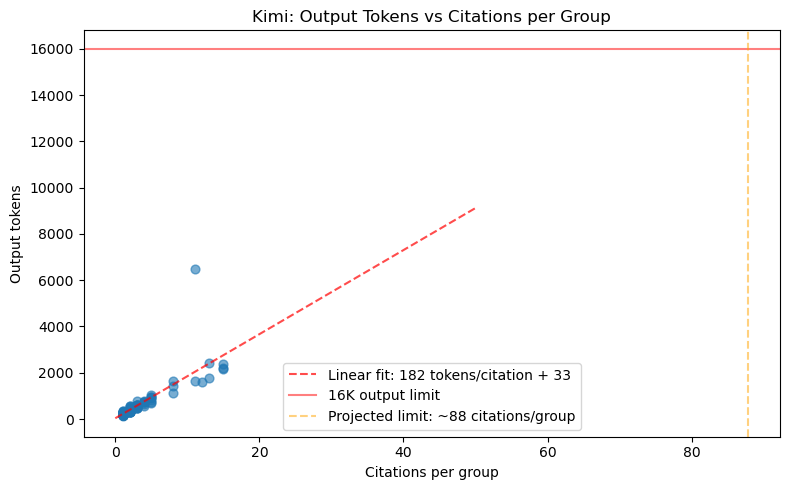

Linear model: ~182 output tokens per citation + 33 overhead
Projected output limit at ~88 citations per group
Current max: 15 citations (6499 tokens, 41%)


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cls['num_citations'], cls['output_tokens'], s=40, alpha=0.6)

# Linear fit
z = np.polyfit(cls['num_citations'], cls['output_tokens'], 1)
p = np.poly1d(z)
x_fit = np.linspace(0, 50, 100)
ax.plot(x_fit, p(x_fit), 'r--', alpha=0.7, label=f'Linear fit: {z[0]:.0f} tokens/citation + {z[1]:.0f}')

ax.axhline(y=KIMI_MAX_OUTPUT, color='red', linestyle='-', alpha=0.5, label=f'16K output limit')

max_citations = (KIMI_MAX_OUTPUT - z[1]) / z[0]
ax.axvline(x=max_citations, color='orange', linestyle='--', alpha=0.5, label=f'Projected limit: ~{max_citations:.0f} citations/group')

# Highlight any >75% groups
high = cls[cls['output_pct'] > 75]
if not high.empty:
    ax.scatter(high['num_citations'], high['output_tokens'], s=100, color='red', zorder=5, label='Above 75%')

ax.set_xlabel('Citations per group')
ax.set_ylabel('Output tokens')
ax.set_title('Kimi: Output Tokens vs Citations per Group')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Linear model: ~{z[0]:.0f} output tokens per citation + {z[1]:.0f} overhead')
print(f'Projected output limit at ~{max_citations:.0f} citations per group')
print(f'Current max: {cls["num_citations"].max()} citations ({cls["output_tokens"].max()} tokens, {cls["output_pct"].max():.0f}%)')

### Kimi: Per-opinion aggregate token usage

How does total Kimi token usage scale with opinion complexity?

In [8]:
per_opinion = cls.groupby('citing_cluster_id').agg(
    num_groups=('group_idx', 'count'),
    total_citations=('num_citations', 'sum'),
    total_input=('input_tokens', 'sum'),
    total_output=('output_tokens', 'sum'),
    max_group_citations=('num_citations', 'max'),
    max_group_output=('output_tokens', 'max'),
    max_group_output_pct=('output_pct', 'max'),
).reset_index()

# Merge with Haiku extraction data
per_opinion = per_opinion.merge(
    ext[['citing_cluster_id', 'input_tokens', 'output_tokens', 'num_cited_cases']],
    on='citing_cluster_id', suffixes=('_kimi', '_haiku')
)
per_opinion['total_cost_input'] = per_opinion['input_tokens'] + per_opinion['total_input']
per_opinion['total_cost_output'] = per_opinion['output_tokens'] + per_opinion['total_output']

print(per_opinion[['citing_cluster_id', 'num_cited_cases', 'num_groups',
                    'total_input', 'total_output', 'max_group_citations',
                    'max_group_output', 'max_group_output_pct']].to_string(index=False))

 citing_cluster_id  num_cited_cases  num_groups  total_input  total_output  max_group_citations  max_group_output  max_group_output_pct
            101625               17          10        55677          3723                    3               771               4.81875
            103543               26          15        89549          5205                    5               684               4.27500
            110274               36          16       108493          6129                   15              2208              13.80000
            110360               69          27       347683         11670                   13              1793              11.20625
            110380               91          29       405324         15999                   15              2368              14.80000
            110420               29          16       131623          5680                    5               890               5.56250
            117849               24          13 

## Opinion Text Length vs Citation Count

Since we don't know the number of citations in advance, we need to base scaling recommendations on opinion text length, which is observable before running the pipeline.

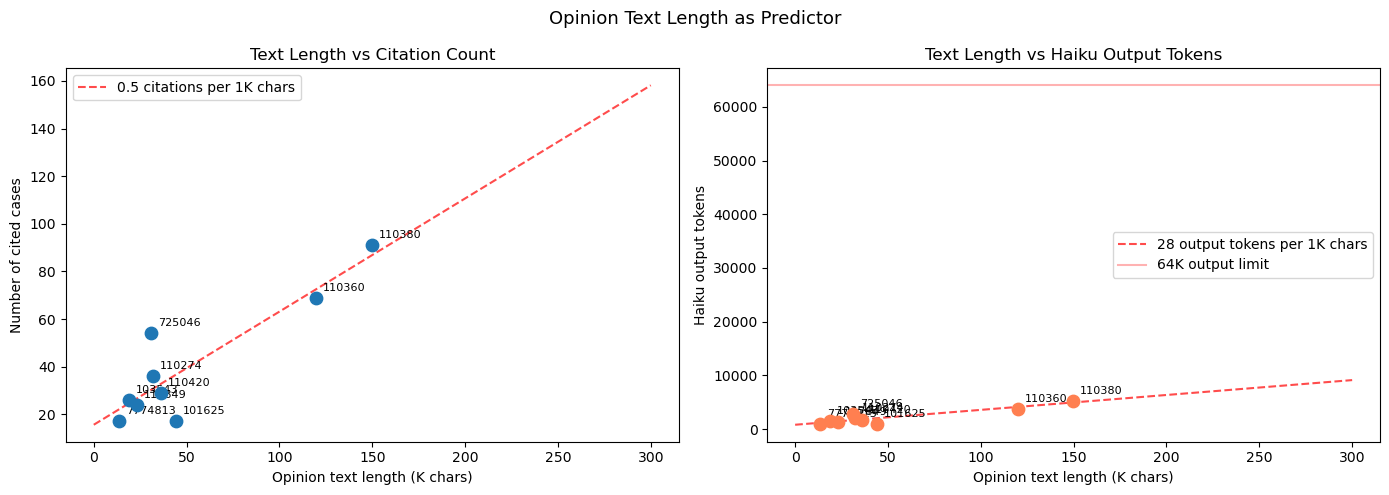

Text length → citation count: R² = 0.801
Linear model: 0.48 citations per 1K chars + 16

Text length → Haiku output tokens: R² = 0.827
Linear model: 28 output tokens per 1K chars + 802


In [10]:
import os

# Load opinion text lengths
opinion_dir = '../data/example_opinion_texts'
text_lengths = {}
for f in os.listdir(opinion_dir):
    if f.endswith('.txt'):
        cid = int(f.replace('.txt', ''))
        text_lengths[cid] = os.path.getsize(os.path.join(opinion_dir, f))

ext['text_length'] = ext['citing_cluster_id'].map(text_lengths)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Text length vs cited cases
ax1.scatter(ext['text_length'] / 1000, ext['num_cited_cases'], s=80, zorder=5)
for _, r in ext.iterrows():
    ax1.annotate(str(int(r['citing_cluster_id'])),
                 (r['text_length'] / 1000, r['num_cited_cases']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

z_tc = np.polyfit(ext['text_length'], ext['num_cited_cases'], 1)
x_fit = np.linspace(0, 300_000, 100)
ax1.plot(x_fit / 1000, np.poly1d(z_tc)(x_fit), 'r--', alpha=0.7,
         label=f'{z_tc[0]*1000:.1f} citations per 1K chars')
ax1.set_xlabel('Opinion text length (K chars)')
ax1.set_ylabel('Number of cited cases')
ax1.set_title('Text Length vs Citation Count')
ax1.legend()

# Text length vs Haiku output tokens
ax2.scatter(ext['text_length'] / 1000, ext['output_tokens'], s=80, zorder=5, color='coral')
for _, r in ext.iterrows():
    ax2.annotate(str(int(r['citing_cluster_id'])),
                 (r['text_length'] / 1000, r['output_tokens']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

z_to = np.polyfit(ext['text_length'], ext['output_tokens'], 1)
ax2.plot(x_fit / 1000, np.poly1d(z_to)(x_fit), 'r--', alpha=0.7,
         label=f'{z_to[0]*1000:.0f} output tokens per 1K chars')
ax2.axhline(y=HAIKU_MAX_OUTPUT, color='red', linestyle='-', alpha=0.3, label='64K output limit')
ax2.set_xlabel('Opinion text length (K chars)')
ax2.set_ylabel('Haiku output tokens')
ax2.set_title('Text Length vs Haiku Output Tokens')
ax2.legend()

plt.suptitle('Opinion Text Length as Predictor', fontsize=13)
plt.tight_layout()
plt.show()

r_squared = np.corrcoef(ext['text_length'], ext['num_cited_cases'])[0, 1] ** 2
print(f'Text length → citation count: R² = {r_squared:.3f}')
print(f'Linear model: {z_tc[0]*1000:.2f} citations per 1K chars + {z_tc[1]:.0f}')

r_squared_to = np.corrcoef(ext['text_length'], ext['output_tokens'])[0, 1] ** 2
print(f'\nText length → Haiku output tokens: R² = {r_squared_to:.3f}')
print(f'Linear model: {z_to[0]*1000:.0f} output tokens per 1K chars + {z_to[1]:.0f}')

In [11]:
# Haiku: project text length at which output limit is hit
# text_length → output_tokens (z_to), output_tokens limit = 64K
haiku_max_text = (HAIKU_MAX_OUTPUT - z_to[1]) / z_to[0]

# Kimi: project text length at which a single-section group would exceed output limit
# Use per-citation output rate and text-length → citation rate to chain the projection
kimi_z = np.polyfit(cls['num_citations'], cls['output_tokens'], 1)
kimi_max_citations = (KIMI_MAX_OUTPUT - kimi_z[1]) / kimi_z[0]

print('=== HAIKU EXTRACTION ===')
print(f'Context window (200K): max usage {ext["input_pct"].max():.1f}% — NO RISK')
print(f'Output tokens (64K):   max usage {ext["output_pct"].max():.1f}% — NO RISK')
print(f'Projected Haiku output limit at ~{haiku_max_text/1000:.0f}K char opinions')

print(f'\n=== KIMI CLASSIFICATION ===')
print(f'Context window (128K): max usage {cls["input_pct"].max():.1f}% — NO RISK')
print(f'Output tokens (16K):   max usage {cls["output_pct"].max():.1f}% — NO RISK')
print(f'Projected Kimi output limit at ~{kimi_max_citations:.0f} citations per group')

print(f'\n=== TEXT-LENGTH-BASED RECOMMENDATIONS ===')
print(f'Text length is a strong predictor of citation count (R² = {r_squared:.3f})')
print(f'  {z_tc[0]*1000:.2f} citations per 1K chars')
print(f'  {z_to[0]*1000:.0f} Haiku output tokens per 1K chars')
print(f'\nHaiku (extraction):')
print(f'  Opinions up to ~{haiku_max_text/1000:.0f}K chars can be processed in a single call.')
print(f'  Current largest (110380): {ext["text_length"].max()/1000:.0f}K chars → {ext["output_pct"].max():.1f}% of output limit.')
print(f'  Page splitting (existing 145K char threshold) provides adequate safety margin.')
print(f'\nKimi (classification):')
print(f'  Max ~{kimi_max_citations:.0f} citations per group before output truncation risk.')
print(f'  With 25% safety margin: cap groups at ~{int(kimi_max_citations * 0.75)} citations.')
print(f'  Current max group: {cls["num_citations"].max()} citations ({cls["output_pct"].max():.1f}% of limit).')

=== HAIKU EXTRACTION ===
Context window (200K): max usage 19.1% — NO RISK
Output tokens (64K):   max usage 8.3% — NO RISK
Projected Haiku output limit at ~2281K char opinions

=== KIMI CLASSIFICATION ===
Context window (128K): max usage 21.1% — NO RISK
Output tokens (16K):   max usage 40.6% — NO RISK
Projected Kimi output limit at ~88 citations per group

=== TEXT-LENGTH-BASED RECOMMENDATIONS ===
Text length is a strong predictor of citation count (R² = 0.801)
  0.48 citations per 1K chars
  28 Haiku output tokens per 1K chars

Haiku (extraction):
  Opinions up to ~2281K chars can be processed in a single call.
  Current largest (110380): 150K chars → 8.3% of output limit.
  Page splitting (existing 145K char threshold) provides adequate safety margin.

Kimi (classification):
  Max ~88 citations per group before output truncation risk.
  With 25% safety margin: cap groups at ~65 citations.
  Current max group: 15 citations (40.6% of limit).
